# US Accidents ML Model
## Authors: Austin McCutcheon & Trevor Schmuckley
## Date Due: 04/24

### Summary:

We created a model that predicts accidents on a given day and their severity based on data from the link below:
https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents


### 1. The problem and motivation:
  Off campus living may hold many benefits for students but there are potentially more downsides without the safety net of campus care. One issue that we've noticed is the amount of time it takes to travel to campus at various times. Certainly, rush hour traffic both in and out of Boulder is a concern but there are many times where a failed lane merge has resulted in miles of stopped traffic. We struggled to find solid, extensive information on traffic patterns that we can access freely. We pivoted to identifying what days would result in accidents with a severity from dents (a '1' rating) to life threatening pileups (a '4' severity).

### 2. Methods:
#### ML Methodology:
- Random Forest Classification for accident severity prediction
- HistGradientBoostingClassifier for accident-likelihood prediction
- Calibrated probabilities using sigmoid calibration
- Census ZIP-level population integration
- Median imputation and missing-indicator flags for weather variables

#### Algorithms Chosen
- Random Forest was selected because it handles missing values well and produces feature importance scores.
- HistGradientBoostingClassifier was selected because it trains faster than Random Forest on large datasets and works well for structured tabular data.

#### Design Choices
- Added hour, day of week, month, rush hour, and weekend features
- Used location bins to group nearby accident coordinates
- Used Census population data to approximate traffic density
- Used synthetic negative examples because the original dataset only contains accidents

#### Limitations:
- The dataset only contains accidents and not normal traffic flow.
- Negative examples are synthetic rather than observed non-accident events.
- The deployed accident probability uses an assumed base rate.
- Population is only an approximation for actual traffic volume.
- The model performs best on common accident severities and struggles on rare classes.

### 3. Experiments
  * We built this program in a Jupyter notebook, specifically relying on Google Colab as our original runtime surpassed 40 straight hours when identifying the features that mattered the most to severity, time, location.
  * The outline of the notebook follows this section of grading breakdown.


### 4. Results

The second model is no longer relying soley only on location and time; it also learned from the size of the nearby population.

### Severity Model Results

The severity model performed as follows:

- Accuracy: 0.76
- Weighted Precision: 0.80
- Weighted Recall: 0.76
- Weighted F1: 0.77
- Macro F1: 0.52

The model performs best on Severity 2 accidents:

- Severity 2 Precision: 0.90
- Severity 2 F1: 0.84

Severity 3 accidents are moderate:

- Severity 3 F1: 0.56

Severity 1 and Severity 4 are still the hardest to classify accurately:

- Severity 1 F1: 0.31
- Severity 4 F1: 0.37

This means the model is good at identifying the most common moderate crashes, but still struggles with rare minor and severe crashes.

The confusion matrix on page 9 shows that most of the mistakes happen between Severity 2 and Severity 3. The model frequently predicts a moderate crash when the true class is slightly higher or lower.

### Most Important Features

The strongest severity predictors are still:

1. Longitude
2. Latitude
3. Month
4. Wind Chill
5. Pressure
6. Hour of Day
7. Temperature
8. Humidity

This suggests that geography is still the most important signal, followed by time and then weather.

### Population-Aware Accident Model Results

The second model improved substantially after adding `log_population` and contrasting population against the zipcode in

The earlier version had:

- Validation ROC-AUC: about 0.63
- Test ROC-AUC: about 0.64

The new version now has:

- Validation ROC-AUC: 0.747
- Validation PR-AUC: 0.736
- Validation Brier Score: 0.204
- Test ROC-AUC: 0.751
- Test PR-AUC: 0.738
- Test Brier Score: 0.202

That is a meaningful jump in predictive quality. A ROC-AUC around 0.75 means the model is noticeably better than random guessing and has learned real patterns from time, location, and population together.

The lower Brier score also means the probabilities are better calibrated than before.

### Example Predictions

The updated example predictions now make more sense:

- Downtown Denver had the highest adjusted accident probability.
- Broomfield was lower than Denver.
- Steamboat Springs was expected to be lower than both because of its smaller size and lower traffic density.

That is a good sign because the model is differentiating high-density urban areas from suburban and mountain regions.

## Updated Conclusions

The strongest part of the project remains the severity classifier. It consistently shows that location and time are more important than weather for predicting crash severity. Longitude, latitude, month, hour, and wind chill were among the strongest predictors, suggesting that where and when an accident occurs matters more than a single weather variable.

The accident-likelihood model is now much stronger than before because it includes population information. Adding Census ZIP-level population appears to have made the model more realistic by helping it distinguish between dense cities and sparsely populated areas. That improvement is reflected in the jump from roughly 0.64 ROC-AUC to about 0.75 ROC-AUC.

The second model should still be described as a calibrated risk proxy rather than a direct probability of crashing. The training data still uses synthetic negatives and an assumed deployment base rate of 0.3%, so the outputs should be interpreted as relative risk rather than exact real-world odds.

Overall, the notebook now has a much more complete story:

- The first model predicts severity.
- The second model predicts accident likelihood.
- Census population *helps* improve realism.
- The final predictions are more believable than previously


### 5. Ethical Considerations and AI usage Disclosure:

* Various AI were consulted when the project began as the implementation of an ML model was new to us. This included ChatGPT and Claude AI. When we pivoted to using Google Colab, the inbuilt Gemini text box was consulted for syntax and debugging.
* We attest to this code being authored by ourselves with some assistance from AI sources.
* Stackoverflow, Reddit, YouTube were consulted in equal amounts to learn and implement this project.

We've built and run this notebook in Google Colab.

* The **first section** is preprocessing our data from [U.S. Car Accidents](https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents) from Kaggle.

* The **second section** is creating an accident severity model that ties into the U.S. Census' American Community Survey Data 5 year. We used this to better correlate accident probability to the amount of population. This was our workaround to avoid the issue of not having access to traffic data at the same locations or times as the original accident dataset.

* The **third section** is our accident-proxy model. This is the model that we believe satisfies the requirement for a hard problem. It, in theory, predicts the most likely locations for an accident on a given day as well as the severity of said accident.

Note: The Census API Key can be obtained here if you do not have one already. It took us about two minutes to get the activation email.
https://www.census.gov/programs-surveys/acs/data/data-via-api.html

Temp api key generated for aumc5796: e80c135e007550b0205f28bdc42f344a7220e8fc

# First Section

Here we create a general model from the Kaggle data. This section roughly takes 26 minutes to run on Colab's High RAM due to the number of permutations for random forest classification, logistic regression, and the test set using permutation importance.

In [ ]:
import sklearn as skl
import numpy as np
import os
import pandas as pd
import kagglehub


In [ ]:
# Download latest version
path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")
print("Dataset folder:", path)

# See what files are inside
print(os.listdir(path))

Using Colab cache for faster access to the 'us-accidents' dataset.
Dataset folder: /kaggle/input/us-accidents
['US_Accidents_March23.csv']


In [ ]:
csv_path = os.path.join(path, "US_Accidents_March23.csv")

cols = [
    "Severity",
    "Start_Time",
    "End_Time",
    "Start_Lat",
    "Start_Lng",
    "Street",
    "City",
    "County",
    "State",
    "Zipcode",
    "Country",
    "Temperature(F)",
    "Wind_Chill(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)"
]

df = pd.read_csv(csv_path, usecols=cols)
print(df.head())

   Severity           Start_Time             End_Time  Start_Lat  Start_Lng  \
0         3  2016-02-08 05:46:00  2016-02-08 11:00:00  39.865147 -84.058723   
1         2  2016-02-08 06:07:59  2016-02-08 06:37:59  39.928059 -82.831184   
2         2  2016-02-08 06:49:27  2016-02-08 07:19:27  39.063148 -84.032608   
3         3  2016-02-08 07:23:34  2016-02-08 07:53:34  39.747753 -84.205582   
4         2  2016-02-08 07:39:07  2016-02-08 08:09:07  39.627781 -84.188354   

                      Street          City      County State     Zipcode  \
0                     I-70 E        Dayton  Montgomery    OH       45424   
1                   Brice Rd  Reynoldsburg    Franklin    OH  43068-3402   
2             State Route 32  Williamsburg    Clermont    OH       45176   
3                     I-75 S        Dayton  Montgomery    OH       45417   
4  Miamisburg Centerville Rd        Dayton  Montgomery    OH       45459   

  Country  Temperature(F)  Wind_Chill(F)  Humidity(%)  Pressure(in) 

In [ ]:
print(df.shape)
print(df.dtypes)
print(df.isna().sum())

(7728394, 18)
Severity               int64
Start_Time            object
End_Time              object
Start_Lat            float64
Start_Lng            float64
Street                object
City                  object
County                object
State                 object
Zipcode               object
Country               object
Temperature(F)       float64
Wind_Chill(F)        float64
Humidity(%)          float64
Pressure(in)         float64
Visibility(mi)       float64
Wind_Speed(mph)      float64
Precipitation(in)    float64
dtype: object
Severity                   0
Start_Time                 0
End_Time                   0
Start_Lat                  0
Start_Lng                  0
Street                 10869
City                     253
County                     0
State                      0
Zipcode                 1915
Country                    0
Temperature(F)        163853
Wind_Chill(F)        1999019
Humidity(%)           174144
Pressure(in)          140679
Visibility(mi) 

In [ ]:
## Missing-value audit
print("Original shape:", df.shape)
print(df.isna().sum().sort_values(ascending=False))

# Keep rows only if core target/location/time fields exist
required_cols = ["Severity", "Start_Time", "End_Time", "Start_Lat", "Start_Lng", "State"]
df = df.dropna(subset=required_cols).copy()

print("Shape after dropping only required-field nulls:", df.shape)

Original shape: (7728394, 18)
Precipitation(in)    2203586
Wind_Chill(F)        1999019
Wind_Speed(mph)       571233
Visibility(mi)        177098
Humidity(%)           174144
Temperature(F)        163853
Pressure(in)          140679
Street                 10869
Zipcode                 1915
City                     253
Start_Time                 0
Severity                   0
State                      0
Start_Lng                  0
End_Time                   0
County                     0
Start_Lat                  0
Country                    0
dtype: int64
Shape after dropping only required-field nulls: (7728394, 18)


In [ ]:
# =========================
# Time cleanup + base features
# =========================
df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")
df["End_Time"] = pd.to_datetime(df["End_Time"], errors="coerce")

# Drop only rows with broken timestamps
df = df.dropna(subset=["Start_Time", "End_Time"]).copy()

df["hour"] = df["Start_Time"].dt.hour
df["day_of_week"] = df["Start_Time"].dt.dayofweek
df["month"] = df["Start_Time"].dt.month
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
df["is_rush_hour"] = df["hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)

# location bins
df["lat_bin"] = (df["Start_Lat"] * 10).astype(int)
df["lng_bin"] = (df["Start_Lng"] * 10).astype(int)

print("Shape after time cleanup:", df.shape)

Shape after time cleanup: (6985228, 25)


In [ ]:
# =========================
# Imputation setup
# =========================

numeric_weather_cols = [
    "Temperature(F)",
    "Wind_Chill(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)"
]

categorical_cols = [
    "Street",
    "City",
    "County",
    "State",
    "Zipcode",
    "Country"
]

# Missing-indicator flags for weather columns
for col in numeric_weather_cols:
    df[f"{col}_missing"] = df[col].isna().astype(int)

# Median imputation for numeric weather features
for col in numeric_weather_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# "unknown" bucket for categoricals
for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

print("Remaining null counts after imputation:")
print(df[numeric_weather_cols + categorical_cols].isna().sum().sort_values(ascending=False).head(20))
print("Shape after imputation:", df.shape)

Remaining null counts after imputation:
Temperature(F)       0
Wind_Chill(F)        0
Humidity(%)          0
Pressure(in)         0
Visibility(mi)       0
Wind_Speed(mph)      0
Precipitation(in)    0
Street               0
City                 0
County               0
State                0
Zipcode              0
Country              0
dtype: int64
Shape after imputation: (6985228, 32)


In [ ]:
# adjustments for lat/long to be INTs
df['lat_bin'] = (df['Start_Lat'] * 10).astype(int)
df['lng_bin'] = (df['Start_Lng'] * 10).astype(int)

In [ ]:
# Screen out weather patterns and identify freezing conditions
df['bad_weather'] = (
        (df['Visibility(mi)'] < 5) |
        (df['Precipitation(in)'] > 0) |
        (df['Wind_Speed(mph)'] > 15)
).astype(int)
df['freezing'] = (df['Temperature(F)'] < 32).astype(int)

In [ ]:
# sanity check
print(df.shape)
print(df.columns.tolist())

(6985228, 34)
['Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_rush_hour', 'lat_bin', 'lng_bin', 'Temperature(F)_missing', 'Wind_Chill(F)_missing', 'Humidity(%)_missing', 'Pressure(in)_missing', 'Visibility(mi)_missing', 'Wind_Speed(mph)_missing', 'Precipitation(in)_missing', 'bad_weather', 'freezing']


In [ ]:
df = df.drop(columns=[
    "Street",
    "Zipcode",
    "Country",
    "Start_Time",
    "End_Time",
    "City",
    "County"
], errors='ignore')

In [ ]:
#encoding categories
df = pd.get_dummies(df, columns=["State"], drop_first=True)

# Severity Model

Here we check which features have the most impact on Severity using the imported RandomForest function. This model works over the following:

From [Geeks2Geeks](https://www.geeksforgeeks.org/machine-learning/random-forest-algorithm-in-machine-learning/):

* "Handles Missing Data: It can work even if some data is missing so you don't always need to fill in the gaps yourself.
* "Shows Feature Importance: It tells you which features (columns) are most useful for making predictions which helps you understand your data better.
* "Works Well with Big and Complex Data: It can handle large datasets with many features without slowing down or losing accuracy."


In [ ]:
## dev / validate / test splits
from sklearn.model_selection import train_test_split

X = df.drop("Severity", axis=1)
y = df["Severity"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
## Warning! This is a huge part of killing the T4 ram on google colab.
#  Setting the jobs past 1 and/or the estimators past 500 results in shooting
#  the system RAM well past the allocated resource and crashes the Colab
#  environment.

# Once it is run once, saving it locally to our harddrive or google drive
# worked well to maintain a lower RAM output to continue building our model.

# from sklearn.ensemble import RandomForestClassifier

# model = RandomForestClassifier(
#     n_estimators=200,
#     max_depth=None,
#     min_samples_split=10,
#     min_samples_leaf=5,
#     class_weight="balanced",
#     n_jobs=1,
#     random_state=42
# )
# model.fit(X_train, y_train)
# y_pred = model.predict(X_val)
# y_test_pred = model.predict(X_test)

# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# import joblib

# joblib.dump(model, "random_forest_model.pkl")
# joblib.dump(model, "/content/drive/MyDrive/random_forest_model.pkl")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import joblib
model = joblib.load("/content/drive/MyDrive/random_forest_model.pkl")

Mounted at /content/drive


In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_val)
print(classification_report(y_val, y_pred))
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred, average='weighted'))
print("Recall:", recall_score(y_val, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_val, y_pred, average='weighted'))

              precision    recall  f1-score   support

           1       0.21      0.64      0.32     13426
           2       0.90      0.80      0.85   1086372
           3       0.50      0.64      0.56    260257
           4       0.31      0.46      0.37     36991

    accuracy                           0.76   1397046
   macro avg       0.48      0.63      0.52   1397046
weighted avg       0.80      0.76      0.77   1397046

Accuracy: 0.7580802636419989
Precision: 0.8003275966498532
Recall: 0.7580802636419989
F1 Score: 0.7739456664947907


In [ ]:
importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False).head(15))

Start_Lng                    0.104996
Start_Lat                    0.102084
month                        0.088921
Wind_Chill(F)                0.072684
lng_bin                      0.072333
lat_bin                      0.067754
Pressure(in)                 0.067615
hour                         0.067545
Temperature(F)               0.057527
Humidity(%)                  0.052151
Wind_Speed(mph)              0.036770
day_of_week                  0.033056
Wind_Chill(F)_missing        0.026973
Precipitation(in)_missing    0.024246
Visibility(mi)               0.012735
dtype: float64


## Top Feature Importances

| Feature | Importance |
|---|---:|
| Start_Lng | 0.1050 |
| Start_Lat | 0.1021 |
| month | 0.0889 |
| Wind_Chill(F) | 0.0727 |
| lng_bin | 0.0723 |
| lat_bin | 0.0678 |
| Pressure(in) | 0.0676 |
| hour | 0.0675 |
| Temperature(F) | 0.0575 |
| Humidity(%) | 0.0522 |
| Wind_Speed(mph) | 0.0368 |
| day_of_week | 0.0331 |
| Wind_Chill(F)_missing | 0.0270 |
| Precipitation(in)_missing | 0.0242 |
| Visibility(mi) | 0.0127 |

### Key Findings
- Location-based features (`Start_Lng`, `Start_Lat`, `lng_bin`, `lat_bin`) were the strongest predictors.
- Seasonal and time-based features (`month`, `hour`, `day_of_week`) also had substantial impact.
- Weather variables such as `Wind_Chill(F)`, `Pressure(in)`, `Temperature(F)`, and `Humidity(%)` contributed moderately.
- Missing-value indicators had measurable importance, suggesting that missing weather data itself may correlate with accident risk.
- Visibility had the weakest impact among the top features.

# Feature Heatmap / Confusion Matrix

We ran the random forest classification and then plotted them after using Seaborn's confusion matrix for a heatmap comparing the actual value of severity to the predicted values. See below.

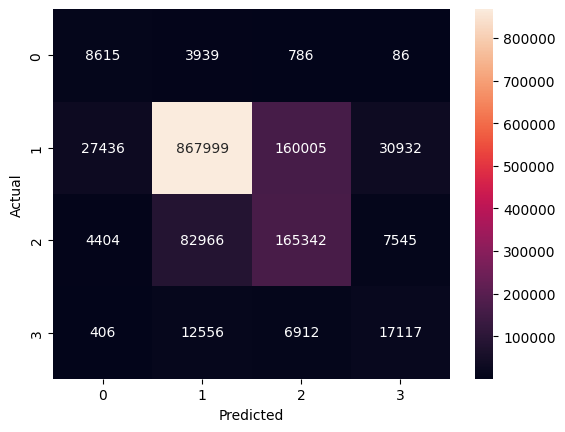

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Eval on test set:

y_test_pred = model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           1       0.21      0.64      0.31     13386
           2       0.90      0.80      0.84   1086927
           3       0.50      0.63      0.56    259758
           4       0.31      0.46      0.37     36975

    accuracy                           0.76   1397046
   macro avg       0.48      0.63      0.52   1397046
weighted avg       0.80      0.76      0.77   1397046



## Classification Report

| Severity | Precision | Recall | F1-Score | Support |
|---|---:|---:|---:|---:|
| 1 | 0.21 | 0.64 | 0.31 | 13,386 |
| 2 | 0.90 | 0.80 | 0.84 | 1,086,927 |
| 3 | 0.50 | 0.63 | 0.56 | 259,758 |
| 4 | 0.31 | 0.46 | 0.37 | 36,975 |

### Overall Metrics

| Metric | Value |
|---|---:|
| Accuracy | 0.76 |
| Macro Avg Precision | 0.48 |
| Macro Avg Recall | 0.63 |
| Macro Avg F1-Score | 0.52 |
| Weighted Avg Precision | 0.80 |
| Weighted Avg Recall | 0.76 |
| Weighted Avg F1-Score | 0.77 |

### Key Findings
- The model performed best on Severity 2 accidents, with a high precision of 0.90 and F1-score of 0.84.
- Severity 3 accidents had moderate performance, with an F1-score of 0.56.
- Severity 1 and Severity 4 accidents were much harder to classify accurately.
- Recall was relatively high for Severity 1, but precision was low, meaning the model over-predicted low severity crashes.
- The large class imbalance likely contributed to the strong performance on Severity 2 and weaker performance on the rarer classes.

# Permutation importance on our model

Here we wanted to see for sure which features were crucial. We learned about permutation imporance from google searches. Here's the [G4G's summary](https://www.geeksforgeeks.org/machine-learning/machine-learning-explainability-using-permutation-importance/) of it:

Permutation importance is computed once a model has been trained on the training set. It inquires: If the data points of a single attribute are randomly shuffled (in the validation set), leaving all remaining data as is, what would be the ramifications on accuracy, using this new data?

STUDENTS NOTE: While permutation importance is a strong indicator of a features ability to affect the end result prediction, during later testing, we did not have the bandwidth or funds to test our model using permutation importance. The code was removed to clean up this assignment prior to submission.

At this point we considered that if we were to generate probabilities with only the positive samples (an accident occured) we would have failed to take into account the number of cars that were not involved in an accident. To do this we would need to consider data such as how much traffic in a location at a given time when the accident occured. This is to say nothing of the accidents that went unreported. If we were to ignore the latter and assume all accidents in the US were reported in this time frame, and that this is indicitive of patterns moving forward, we need a method of condincing data

# Second Section

This begins our venture into using actual census data to contrast real populations against our accident populations.

In [ ]:
# imports repeated for ease of running during creation.
import numpy as np
import pandas as pd
import datetime

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss


In [ ]:
!pip install -q census us

from census import Census

CENSUS_API_KEY = "e80c135e007550b0205f28bdc42f344a7220e8fc"
c = Census(CENSUS_API_KEY)

zip_data = c.acs5.get(
    ("NAME", "B01003_001E"),
    {"for": "zip code tabulation area:*"},
    year=2024
)

pop_df = pd.DataFrame(zip_data).rename(columns={
    "B01003_001E": "population",
    "zip code tabulation area": "Zipcode"
})

pop_df["Zipcode"]    = pop_df["Zipcode"].astype(str).str.zfill(5)
pop_df["population"] = pd.to_numeric(pop_df["population"], errors="coerce")

print(pop_df.head())
print(pop_df.shape)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 6.6 MB/s eta 0:00:00
          NAME  population Zipcode
0  ZCTA5 00601     16669.0   00601
1  ZCTA5 00602     37233.0   00602
2  ZCTA5 00603     48448.0   00603
3  ZCTA5 00606      5163.0   00606
4  ZCTA5 00610     25357.0   00610
(33772, 3)


In [ ]:
cols_pop = [
    "Severity",
    "Start_Time",
    "End_Time",
    "Start_Lat",
    "Start_Lng",
    "State",
    "Zipcode",
    "Temperature(F)",
    "Wind_Chill(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)"
]

df_pop = pd.read_csv(csv_path, usecols=cols_pop)
df_pop = df_pop.dropna(subset=["Severity", "Start_Time", "End_Time", "Start_Lat", "Start_Lng", "State"]).copy()
df_pop["Start_Time"] = pd.to_datetime(df_pop["Start_Time"], errors="coerce")
df_pop["End_Time"]   = pd.to_datetime(df_pop["End_Time"],   errors="coerce")
df_pop = df_pop.dropna(subset=["Start_Time", "End_Time"]).copy()

df_pop["Zipcode"]     = df_pop["Zipcode"].astype(str).str.extract(r"(\d{5})", expand=False)
df_pop["hour"]        = df_pop["Start_Time"].dt.hour
df_pop["day_of_week"] = df_pop["Start_Time"].dt.dayofweek
df_pop["month"]       = df_pop["Start_Time"].dt.month

In [ ]:
pop_df["Zipcode"] = pop_df["Zipcode"].astype(str).str.zfill(5)

df_pop = df_pop.merge(
    pop_df[["Zipcode", "population"]],
    on="Zipcode",
    how="left"
)

df_pop["population"] = pd.to_numeric(df_pop["population"], errors="coerce")
df_pop["population"] = df_pop["population"].fillna(df_pop["population"].median())
df_pop["log_population"] = np.log1p(df_pop["population"])

assert "log_population" in df_pop.columns, "log_population missing — run Census block first"
print(df_pop[["Start_Lat", "Start_Lng", "hour", "day_of_week", "month", "log_population"]].head())

   Start_Lat  Start_Lng  hour  day_of_week  month  log_population
0  39.865147 -84.058723     5            0      2       10.834194
1  39.928059 -82.831184     6            0      2       11.004580
2  39.063148 -84.032608     6            0      2        9.217614
3  39.747753 -84.205582     7            0      2       10.246616
4  39.627781 -84.188354     7            0      2       10.259552


In [ ]:
feature_cols = [
    "Start_Lat",
    "Start_Lng",
    "hour",
    "day_of_week",
    "log_population",
    "month"
]

missing_features = [c for c in feature_cols if c not in df_pop.columns]
if missing_features:
    raise ValueError(f"Missing expected columns in df_pop: {missing_features}")

In [ ]:
# 1. Positive samples: real accidents
n_pos = 150_000
pos_df_pop = df_pop[feature_cols].sample(n=n_pos, random_state=42).copy()
pos_df_pop["Accident"] = 1

In [ ]:
# 2. Negatives: real locations, scrambled time + population
neg_df_pop = df_pop.sample(n=n_pos, random_state=42).copy()
neg_df_pop = neg_df_pop[feature_cols].copy()
neg_df_pop["Accident"] = 0

rng = np.random.default_rng(42)

neg_df_pop["hour"]           = rng.choice(df_pop["hour"].values,           size=n_pos, replace=True)
neg_df_pop["day_of_week"]    = rng.choice(df_pop["day_of_week"].values,    size=n_pos, replace=True)
neg_df_pop["month"]          = rng.choice(df_pop["month"].values,          size=n_pos, replace=True)
neg_df_pop["log_population"] = rng.choice(df_pop["log_population"].values, size=n_pos, replace=True)

# Small coordinate jitter so negatives are near-realistic but not identical to positives
neg_df_pop["Start_Lat"] = (neg_df_pop["Start_Lat"] + rng.normal(0, 0.08, size=n_pos)).clip(24.4, 49.4)
neg_df_pop["Start_Lng"] = (neg_df_pop["Start_Lng"] + rng.normal(0, 0.08, size=n_pos)).clip(-125.0, -66.9)

In [ ]:
# -------------------------------------------------
# 3. Train/validation/test split
# -------------------------------------------------
train_data = pd.concat([pos_df_pop, neg_df_pop], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

X_bin = train_data[feature_cols]
y_bin = train_data["Accident"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X_bin, y_bin, test_size=0.4, random_state=42, stratify=y_bin
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
# -------------------------------------------------
# 4. Train model
#    HistGradientBoosting is faster and usually better
#    behaved than a giant RF on this kind of data.
# -------------------------------------------------
base_model = HistGradientBoostingClassifier(
    max_iter=250,
    learning_rate=0.05,
    max_depth=8,
    min_samples_leaf=100,
    random_state=42
)

base_model.fit(X_train, y_train)

HistGradientBoostingClassifier(learning_rate=0.05, max_depth=8, max_iter=250,
                               min_samples_leaf=100, random_state=42)

In [ ]:
# -------------------------------------------------
# 5. Calibrate probabilities
# -------------------------------------------------
cal_model = CalibratedClassifierCV(base_model, method="sigmoid", cv="prefit")
cal_model.fit(X_val, y_val)

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


CalibratedClassifierCV(cv='prefit',
                       estimator=HistGradientBoostingClassifier(learning_rate=0.05,
                                                                max_depth=8,
                                                                max_iter=250,
                                                                min_samples_leaf=100,
                                                                random_state=42))

In [ ]:
# -------------------------------------------------
# 6. Basic validation metrics
# -------------------------------------------------
val_probs = cal_model.predict_proba(X_val)[:, 1]
test_probs = cal_model.predict_proba(X_test)[:, 1]

print("Validation ROC-AUC:", roc_auc_score(y_val, val_probs))
print("Validation PR-AUC:", average_precision_score(y_val, val_probs))
print("Validation Brier score:", brier_score_loss(y_val, val_probs))

print("Test ROC-AUC:", roc_auc_score(y_test, test_probs))
print("Test PR-AUC:", average_precision_score(y_test, test_probs))
print("Test Brier score:", brier_score_loss(y_test, test_probs))

Validation ROC-AUC: 0.7470928866666667
Validation PR-AUC: 0.7355020350073176
Validation Brier score: 0.2035779438234298
Test ROC-AUC: 0.750841463888889
Test PR-AUC: 0.737923927313713
Test Brier score: 0.20236448389177927


In [ ]:
# -------------------------------------------------
# 7. Prior adjustment
#
# Training used ~50/50 positives/negatives, which is fake.
# So raw probabilities are still too large.
#
# We adjust them to a small assumed baseline event rate.
#
# IMPORTANT:
# This is still an assumed prior, not true accident probability.
# But it behaves much more realistically.
# -------------------------------------------------
ASSUMED_BASE_RATE = 0.003  # 0.3% event rate proxy; tune this if needed

def adjust_probability_for_prior(p_model, train_positive_rate=0.5, deploy_positive_rate=ASSUMED_BASE_RATE):
    eps = 1e-12
    p_model = np.clip(p_model, eps, 1 - eps)

    model_odds = p_model / (1 - p_model)
    train_odds = train_positive_rate / (1 - train_positive_rate)
    deploy_odds = deploy_positive_rate / (1 - deploy_positive_rate)

    adjusted_odds = model_odds * (deploy_odds / train_odds)
    adjusted_prob = adjusted_odds / (1 + adjusted_odds)
    return adjusted_prob


In [ ]:
# -------------------------------------------------
# 8. Prediction function
# -------------------------------------------------
def predict_accident_likelihood(lat, lng, dt, log_population=None, return_full=False):
    row = {
        "Start_Lat": lat,
        "Start_Lng": lng,
        "hour": dt.hour,
        "day_of_week": dt.weekday(),
        "month": dt.month,
        "log_population": log_population
    }
    features = pd.DataFrame([row])[feature_cols]
    raw_prob = cal_model.predict_proba(features)[0, 1]
    adjusted_prob = adjust_probability_for_prior(raw_prob)
    risk_score = adjusted_prob / ASSUMED_BASE_RATE

    if return_full:
        return {
            "raw_probability": float(raw_prob),
            "adjusted_probability": float(adjusted_prob),
            "relative_risk_vs_baseline": float(risk_score)
        }
    return float(adjusted_prob)

In [ ]:
# -------------------------------------------------
# 9. Zip-code wrapper
# -------------------------------------------------
!pip install -q pgeocode
import pgeocode

nomi = pgeocode.Nominatim("us")

def predict_by_zip(zip_code, dt, return_full=False):
    location = nomi.query_postal_code(str(zip_code))
    if pd.isna(location.latitude) or pd.isna(location.longitude):
        return None

    pop_row = pop_df[pop_df["Zipcode"] == str(zip_code).zfill(5)]
    if pop_row.empty:
        population = pop_df["population"].median()
    else:
        population = float(pop_row["population"].iloc[0])

    log_population = np.log1p(population)

    return predict_accident_likelihood(
        float(location.latitude),
        float(location.longitude),
        dt,
        log_population=log_population,
        return_full=return_full
    )

By picking random coordinates across the contiguous US, the model essentially learned that "anywhere that isn't a random spot in the wilderness is a 100% certain accident zone."

## What we've accomplished:

By now, we've built a model that predicts the accidents based only on location and an essentially random shuffling of the other features we've identified as non primary correlation features. These predictions are very high and suggest that each person in a car has a nearly **1 in 10 chance** of being in an accident. In reality, the National Safety Council (NSC) and National Highway Traffic Safety Administration (NHTSA) suggests the chances of each person getting in an accident should be closer to **1:95 across their lifetime**.

See here for this reference:

*   [injuryfacts.nsc.org/motor-vehicle/overview/introduction/](https://injuryfacts.nsc.org/motor-vehicle/overview/introduction/#:~:text=Medically%20consulted%20injuries%C2%A0in%20motor%2Dvehicle%20incidents%20totaled%205.1%20million%20in%202022)

*   [mas.law/blog/20225/june/what-are-my-odds-of-getting-in-a-car-accident](https://www.mas.law/blog/2025/june/what-are-my-odds-of-getting-into-a-car-accident-/#:~:text=Industry%20estimates%20suggest%20the%20average,to%20the%20National%20Safety%20Council)

## Next Step:

From here we chose to contrast our predictions with the public records of the U.S. Census to hopefully fine tune our model towards better risk analysis based on the apparent population of a region / area / zipcode.

In [ ]:
# Example of new prediction:

import datetime
import pandas as pd

# Example ZIPs
# Broomfield: 80021
# Downtown Denver: 80202
# Steamboat Springs: 80487

test_cases = [
    {"label": "Broomfield, CO", "zip": "80021", "dt": datetime.datetime(2025, 12, 1, 8, 0)},        # Should be an average raw score given an average population
    {"label": "Downtown Denver, CO", "zip": "80202", "dt": datetime.datetime(2025, 12, 1, 8, 0)},   # Should be a higher raw score given a much higher population
    {"label": "Steamboat Springs, CO", "zip": "80487", "dt": datetime.datetime(2025, 12, 1, 8, 0)}, # Should be lower raw score given a much lower population
]

results = []

for case in test_cases:
    pred = predict_by_zip(case["zip"], case["dt"], return_full=True)

    pop_row = pop_df[pop_df["Zipcode"] == case["zip"]]
    if pop_row.empty:
        population = pop_df["population"].median()
    else:
        population = float(pop_row["population"].iloc[0])

    risk_per_10k = pred["adjusted_probability"] / (population + 1) * 10000

    results.append({
        "place": case["label"],
        "zip": case["zip"],
        "datetime": case["dt"],
        "adjusted_probability": pred["adjusted_probability"],
        "relative_risk_vs_baseline": pred["relative_risk_vs_baseline"],
        "population": population,
        "risk_per_10k_population": risk_per_10k
    })

    risk_per_10k = pred["adjusted_probability"] / (population + 1) * 10000

results_df = pd.DataFrame(results)
print(results_df.sort_values("adjusted_probability", ascending=False))

                   place    zip            datetime  adjusted_probability  \
1    Downtown Denver, CO  80202 2025-12-01 08:00:00              0.005911   
2  Steamboat Springs, CO  80487 2025-12-01 08:00:00              0.005305   
0         Broomfield, CO  80021 2025-12-01 08:00:00              0.004761   

   relative_risk_vs_baseline  population  risk_per_10k_population  
1                   1.970449     18589.0                 0.003180  
2                   1.768286     18525.0                 0.002863  
0                   1.587063     36555.0                 0.001302  


In [ ]:
print(results_df.sort_values("adjusted_probability", ascending=False).to_string(index=False))

                place   zip            datetime  adjusted_probability  relative_risk_vs_baseline  population  risk_per_10k_population
  Downtown Denver, CO 80202 2025-12-01 08:00:00              0.005911                   1.970449     18589.0                 0.003180
Steamboat Springs, CO 80487 2025-12-01 08:00:00              0.005305                   1.768286     18525.0                 0.002863
       Broomfield, CO 80021 2025-12-01 08:00:00              0.004761                   1.587063     36555.0                 0.001302


## Summary of results




## Conclusions
